In [1]:
%pip install transformers torch scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [3]:
df_train = pd.read_csv('../data/train.csv')
df_val = pd.read_csv('../data/val.csv')
df_test = pd.read_csv('../data/test.csv')

print("Train:", len(df_train))
print("Val:  ", len(df_val))
print("Test: ", len(df_test))

Train: 1574
Val:   197
Test:  197


In [4]:
label2id = {'BRCA': 0, 'LUAD': 1, 'PRAD': 2}
id2label = {0: 'BRCA', 1: 'LUAD', 2: 'PRAD'}

df_train['label'] = df_train['cancer_type'].map(label2id)
df_val['label'] = df_val['cancer_type'].map(label2id)
df_test['label'] = df_test['cancer_type'].map(label2id)

print(df_train['label'].value_counts())

label
0    828
1    390
2    356
Name: count, dtype: int64


In [5]:
tokenizer = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
print("Tokenizer loaded")

Tokenizer loaded


In [6]:
class PathologyDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [7]:
train_dataset = PathologyDataset(df_train, tokenizer)
val_dataset = PathologyDataset(df_val, tokenizer)
test_dataset = PathologyDataset(df_test, tokenizer)

print("Train samples:", len(train_dataset))
print("Val samples:  ", len(val_dataset))
print("Test samples: ", len(test_dataset))

Train samples: 1574
Val samples:   197
Test samples:  197


In [8]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 99
Val batches: 13
Test batches: 13


In [9]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model = AutoModelForSequenceClassification.from_pretrained(
    'emilyalsentzer/Bio_ClinicalBERT',
    num_labels=3
)
model = model.to(device)

print("Device:", device)
print("Model loaded")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Conside

Device: mps
Model loaded


In [10]:
optimizer = AdamW(model.parameters(), lr=2e-5)

print("Optimizer ready")

Optimizer ready


In [11]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [12]:
def evaluate(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    return auc

In [14]:
epochs = 3
train_losses = []
val_aucs = []

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_auc = evaluate(model, val_loader, device)

    train_losses.append(train_loss)
    val_aucs.append(val_auc)

    print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")

Epoch 1 | Loss: 0.3525 | Val AUC: 1.0000
Epoch 2 | Loss: 0.0101 | Val AUC: 1.0000
Epoch 3 | Loss: 0.0036 | Val AUC: 1.0000


In [15]:
test_auc = evaluate(model, test_loader, device)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 1.0000


In [16]:
model.save_pretrained('../results/clinicalbert_first512')
tokenizer.save_pretrained('../results/clinicalbert_first512')
print("Model saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved


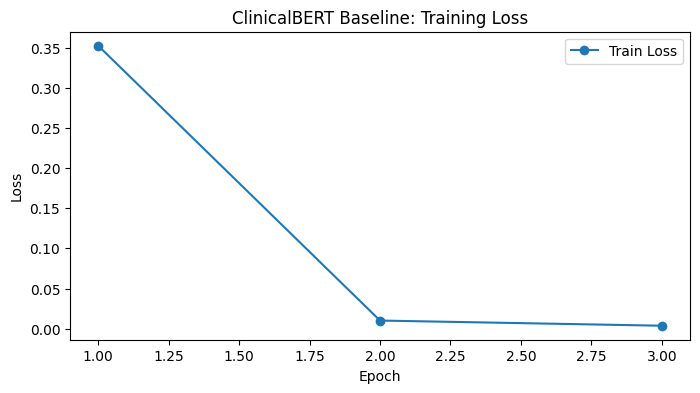

In [17]:
plt.figure(figsize=(8, 4))
plt.plot([1, 2, 3], train_losses, marker='o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ClinicalBERT Baseline: Training Loss')
plt.legend()
plt.savefig('../results/baseline_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()